<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/Lab_15_From_Regression_to_Machine_Learning_%E2%80%94_The_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [14]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


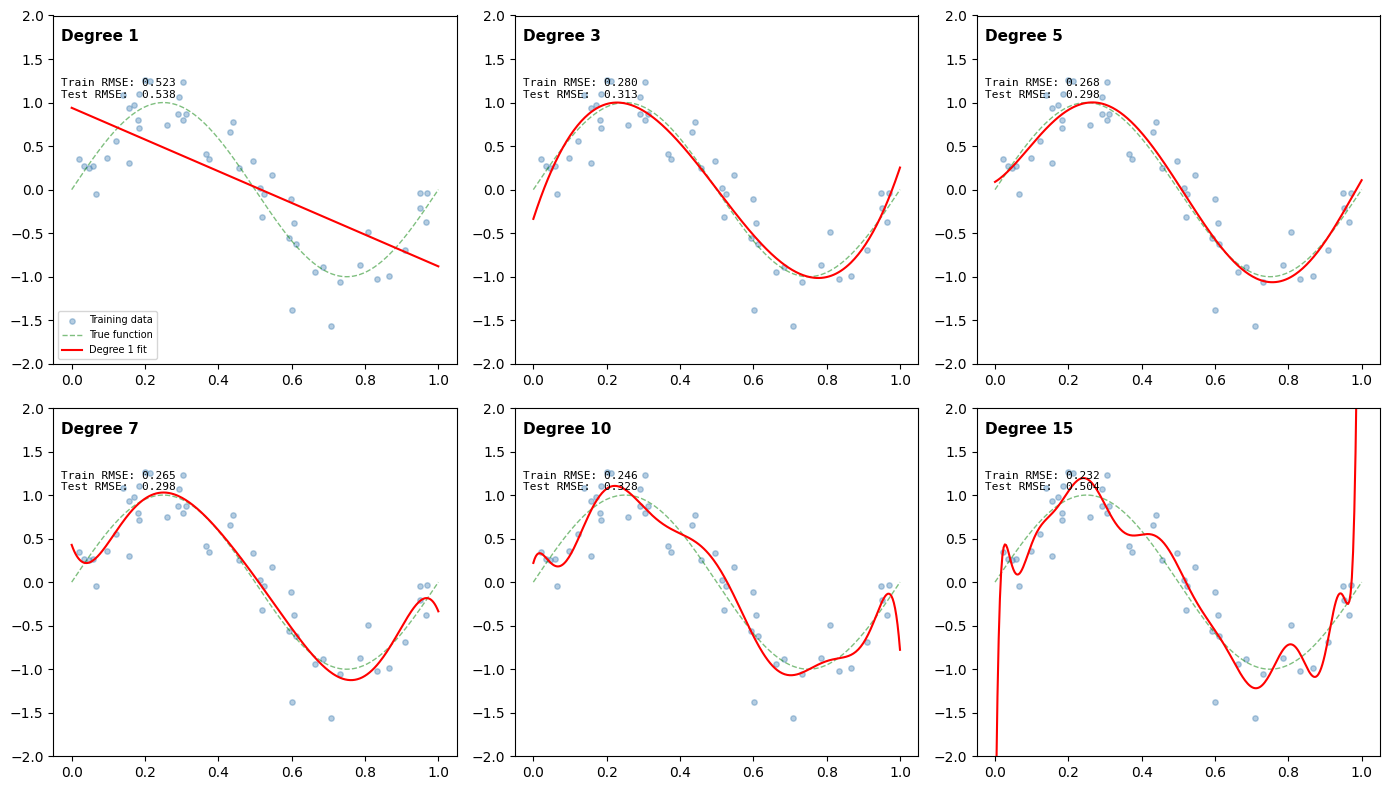

In [15]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

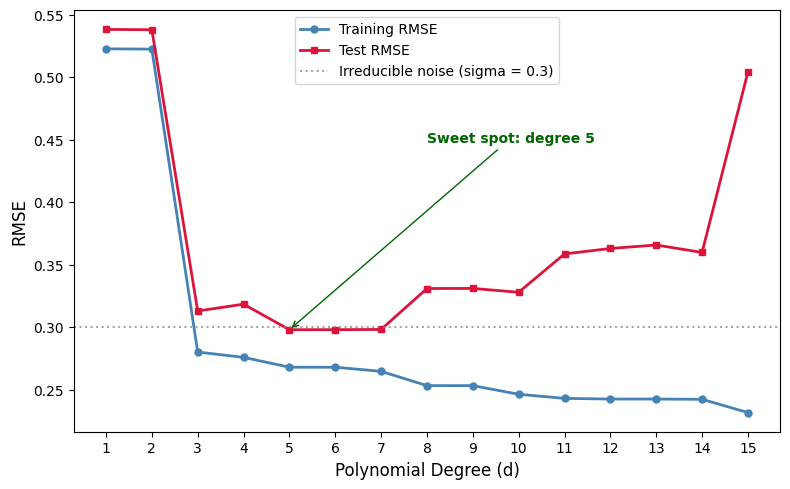

In [20]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()

In [21]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [22]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


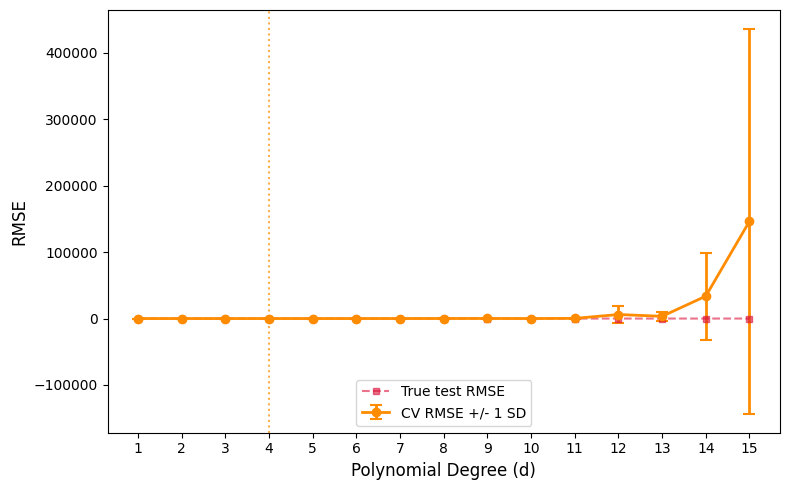

CV-selected degree: 4
True optimal degree: 5


In [23]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [24]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [25]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


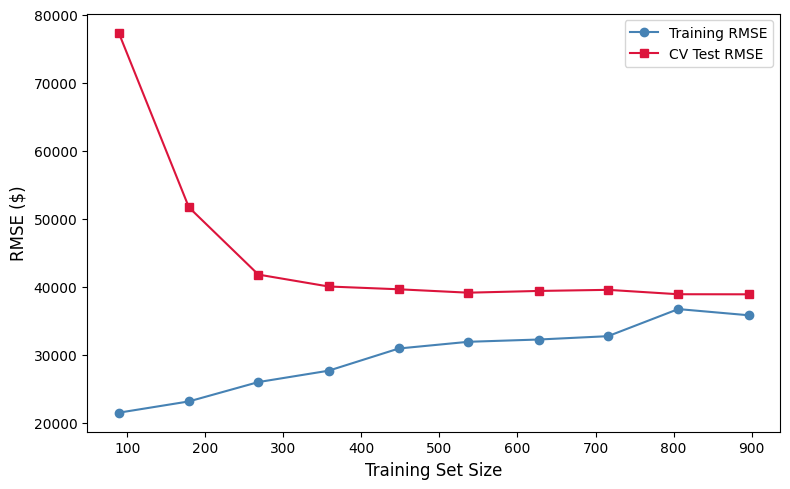

In [26]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    make_pipeline(StandardScaler(), LinearRegression()),
    X_ames, y_ames,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error'
)

train_rmse_lc = np.sqrt(-train_scores).mean(axis=1)
test_rmse_lc = np.sqrt(-test_scores).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_rmse_lc, 'o-', color='steelblue',
        label='Training RMSE')
ax.plot(train_sizes, test_rmse_lc, 's-', color='crimson',
        label='CV Test RMSE')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('RMSE ($)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [35]:
"""
Bias-Variance Tradeoff Dashboard for Google Colab
==================================================
Interactive visualization using ipywidgets - works natively in Colab!

Just run this entire cell to launch the dashboard.
"""

# Install/import dependencies
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import ipywidgets as widgets
from IPython.display import display, clear_output
from functools import lru_cache

# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------
def true_function(x):
    """Ground truth: y = sin(2*pi*x)"""
    return np.sin(2 * np.pi * x)


def generate_data(n_points, sigma, seed=None):
    """Generate synthetic data with Gaussian noise."""
    rng = np.random.RandomState(seed)
    x = rng.uniform(0, 1, n_points)
    y = true_function(x) + rng.normal(0, sigma, n_points)
    return x, y


def fit_polynomial(x_train, y_train, degree):
    """Fit a polynomial regression model."""
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=True),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    return model


def compute_rmse(y_true, y_pred):
    """Compute Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def compute_complexity_curves(x_train, y_train, x_test, y_test, max_degree=15):
    """Compute training and test RMSE for degrees 1 to max_degree."""
    train_rmse, test_rmse = [], []
    for deg in range(1, max_degree + 1):
        model = fit_polynomial(x_train, y_train, deg)
        train_rmse.append(compute_rmse(y_train, model.predict(x_train.reshape(-1, 1))))
        test_rmse.append(compute_rmse(y_test, model.predict(x_test.reshape(-1, 1))))
    return np.array(train_rmse), np.array(test_rmse)


# Cache the expensive bootstrap computation
@lru_cache(maxsize=32)
def compute_bias_variance_decomposition(n_train, sigma, max_degree=15, n_bootstrap=100):
    """
    Estimate Bias², Variance, and MSE via bootstrap resampling.
    Cached for performance.
    """
    n_test_points = 200
    x_test = np.linspace(0, 1, n_test_points)
    y_true = true_function(x_test)

    bias_sq, variance, mse = [], [], []

    for deg in range(1, max_degree + 1):
        predictions = np.zeros((n_bootstrap, n_test_points))

        for b in range(n_bootstrap):
            x_train, y_train = generate_data(n_train, sigma, seed=b * 1000 + deg)
            model = fit_polynomial(x_train, y_train, deg)
            predictions[b, :] = model.predict(x_test.reshape(-1, 1))

        mean_pred = predictions.mean(axis=0)
        bias_sq.append(np.mean((mean_pred - y_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))
        mse.append(np.mean((predictions - y_true) ** 2))

    return np.array(bias_sq), np.array(variance), np.array(mse)


# -----------------------------------------------------------------------------
# Create Interactive Dashboard
# -----------------------------------------------------------------------------
def create_dashboard():
    """Create and display the interactive dashboard."""

    # Create sliders
    degree_slider = widgets.IntSlider(
        value=3, min=1, max=15, step=1,
        description='Degree:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='300px')
    )

    sigma_slider = widgets.FloatSlider(
        value=0.3, min=0.1, max=1.0, step=0.05,
        description='Noise (σ):',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='300px')
    )

    n_train_slider = widgets.IntSlider(
        value=50, min=20, max=200, step=10,
        description='N Train:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='300px')
    )

    n_bootstrap_slider = widgets.IntSlider(
        value=100, min=20, max=200, step=20,
        description='Bootstrap:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='300px')
    )

    # Output area for plots
    output = widgets.Output()

    # Status label
    status_label = widgets.HTML(value="<b>Ready</b>")

    def update_plots(change=None):
        """Update all plots when sliders change."""
        with output:
            clear_output(wait=True)

            # Get current values
            degree = degree_slider.value
            sigma = sigma_slider.value
            n_train = n_train_slider.value
            n_bootstrap = n_bootstrap_slider.value

            # Generate data
            x_train, y_train = generate_data(n_train, sigma, seed=42)
            x_test, y_test = generate_data(200, sigma, seed=123)

            # Fit current model
            current_model = fit_polynomial(x_train, y_train, degree)

            # Fine grid for plotting
            x_plot = np.linspace(0, 1, 300)
            y_true_plot = true_function(x_plot)
            y_pred_plot = current_model.predict(x_plot.reshape(-1, 1))

            # Create figure with 3 subplots
            fig = plt.figure(figsize=(16, 12))

            # ============================================================
            # PANEL 1: Polynomial Fit (top left)
            # ============================================================
            ax1 = fig.add_subplot(2, 2, 1)

            ax1.plot(x_plot, y_true_plot, 'g-', lw=2.5, label='True: sin(2πx)')
            ax1.scatter(x_train, y_train, c='blue', alpha=0.6, s=40,
                        label=f'Training (n={n_train})', zorder=5)
            ax1.plot(x_plot, y_pred_plot, 'r-', lw=2,
                     label=f'Fit (degree={degree})')

            # Quick bootstrap for confidence band
            quick_preds = []
            for b in range(30):
                x_b, y_b = generate_data(n_train, sigma, seed=b + 1000)
                m = fit_polynomial(x_b, y_b, degree)
                quick_preds.append(m.predict(x_plot.reshape(-1, 1)))
            quick_preds = np.array(quick_preds)
            mean_pred = quick_preds.mean(axis=0)
            std_pred = quick_preds.std(axis=0)
            ax1.fill_between(x_plot, mean_pred - 2*std_pred, mean_pred + 2*std_pred,
                             alpha=0.2, color='red', label='±2σ spread')

            ax1.set_xlabel('x', fontsize=11)
            ax1.set_ylabel('y', fontsize=11)
            ax1.set_title(f'Polynomial Regression (Degree {degree})', fontsize=13, fontweight='bold')
            ax1.legend(loc='upper right', fontsize=9)
            ax1.set_xlim(-0.05, 1.05)
            ax1.set_ylim(-2, 2)
            ax1.grid(True, alpha=0.3)

            # Add metrics text
            train_rmse_curr = compute_rmse(y_train, current_model.predict(x_train.reshape(-1, 1)))
            test_rmse_curr = compute_rmse(y_test, current_model.predict(x_test.reshape(-1, 1)))
            metrics_text = f'Train RMSE: {train_rmse_curr:.4f}\nTest RMSE: {test_rmse_curr:.4f}'
            ax1.text(0.02, 0.98, metrics_text, transform=ax1.transAxes, fontsize=10,
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            # ============================================================
            # PANEL 2: Complexity Curves (top right)
            # ============================================================
            ax2 = fig.add_subplot(2, 2, 2)

            train_rmse_all, test_rmse_all = compute_complexity_curves(
                x_train, y_train, x_test, y_test, max_degree=15
            )
            degrees = np.arange(1, 16)

            ax2.plot(degrees, train_rmse_all, 'b-o', lw=2, markersize=6, label='Training RMSE')
            ax2.plot(degrees, test_rmse_all, 'r-o', lw=2, markersize=6, label='Test RMSE')
            ax2.axvline(x=degree, color='green', linestyle='--', lw=2.5,
                        label=f'Selected (d={degree})')

            optimal_deg = degrees[np.argmin(test_rmse_all)]
            ax2.axvline(x=optimal_deg, color='orange', linestyle=':', lw=2,
                        label=f'Optimal (d={optimal_deg})')

            ax2.set_xlabel('Polynomial Degree', fontsize=11)
            ax2.set_ylabel('RMSE', fontsize=11)
            ax2.set_title('Model Complexity vs Error', fontsize=13, fontweight='bold')
            ax2.legend(loc='upper right', fontsize=9)
            ax2.set_xticks(degrees)
            ax2.set_ylim(0, max(test_rmse_all.max(), train_rmse_all.max()) * 1.1)
            ax2.grid(True, alpha=0.3)

            # Annotate regions
            ax2.annotate('Underfitting', xy=(2, test_rmse_all[1]*0.95), fontsize=10, color='gray')
            ax2.annotate('Overfitting', xy=(12, test_rmse_all[11]*0.95), fontsize=10, color='gray')

            # ============================================================
            # PANEL 3: Bias-Variance Decomposition (bottom, spans both columns)
            # ============================================================
            ax3 = fig.add_subplot(2, 1, 2)

            status_label.value = "<b style='color:orange'>Computing bias-variance decomposition...</b>"

            bias_sq, variance, mse = compute_bias_variance_decomposition(
                n_train, sigma, max_degree=15, n_bootstrap=n_bootstrap
            )

            status_label.value = "<b style='color:green'>Ready</b>"

            irreducible = sigma ** 2

            ax3.plot(degrees, bias_sq, 'b-o', lw=2, markersize=7, label='Bias²')
            ax3.plot(degrees, variance, 'r-o', lw=2, markersize=7, label='Variance')
            ax3.plot(degrees, mse, 'k-s', lw=2, markersize=7, label='MSE (empirical)')
            ax3.plot(degrees, bias_sq + variance + irreducible, 'g--', lw=2,
                     label=f'Bias² + Var + σ²')
            ax3.axhline(y=irreducible, color='gray', linestyle=':', lw=1.5,
                        label=f'Irreducible (σ²={irreducible:.3f})')
            ax3.axvline(x=degree, color='purple', linestyle='--', lw=2.5, alpha=0.7,
                        label=f'Selected (d={degree})')

            ax3.set_xlabel('Polynomial Degree', fontsize=11)
            ax3.set_ylabel('Error', fontsize=11)
            ax3.set_title('Bias-Variance Decomposition (Bootstrap Estimation)', fontsize=13, fontweight='bold')
            ax3.legend(loc='upper right', fontsize=9, ncol=2)
            ax3.set_xticks(degrees)
            ax3.set_ylim(0, max(mse.max(), (bias_sq + variance + irreducible).max()) * 1.1)
            ax3.grid(True, alpha=0.3)

            # Add verification box
            idx = degree - 1
            theoretical = bias_sq[idx] + variance[idx] + irreducible
            verify_text = (f'At degree {degree}:\n'
                          f'  Bias² = {bias_sq[idx]:.4f}\n'
                          f'  Variance = {variance[idx]:.4f}\n'
                          f'  σ² = {irreducible:.4f}\n'
                          f'  ─────────────\n'
                          f'  Sum = {theoretical:.4f}\n'
                          f'  MSE = {mse[idx]:.4f}\n'
                          f'  Δ = {abs(theoretical - mse[idx]):.4f} ✓')
            ax3.text(0.02, 0.98, verify_text, transform=ax3.transAxes, fontsize=9,
                     verticalalignment='top', family='monospace',
                     bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

            plt.tight_layout()
            plt.show()

    # Connect sliders to update function
    degree_slider.observe(update_plots, names='value')
    sigma_slider.observe(update_plots, names='value')
    n_train_slider.observe(update_plots, names='value')
    n_bootstrap_slider.observe(update_plots, names='value')

    # Layout
    controls = widgets.VBox([
        widgets.HTML("<h2>🎛️ Bias-Variance Tradeoff Explorer</h2>"),
        widgets.HTML("<p>Adjust sliders to see how polynomial complexity affects bias and variance.</p>"),
        widgets.HBox([
            widgets.VBox([degree_slider, sigma_slider], layout=widgets.Layout(margin='0 20px 0 0')),
            widgets.VBox([n_train_slider, n_bootstrap_slider])
        ]),
        status_label,
        widgets.HTML("<hr>")
    ])

    dashboard = widgets.VBox([controls, output])

    # Display dashboard
    display(dashboard)

    # Initial plot
    update_plots()


# -----------------------------------------------------------------------------
# Run the dashboard
# -----------------------------------------------------------------------------
create_dashboard()